In [20]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

In [2]:
smonth = 4
emonth = 9

In [3]:
# JdF box, including cells to 50 m depth
ii1, ii2 = 300, 365
jj1, jj2 = 50, 100
km = 24

In [4]:
pp = xr.open_dataset(
    '/results2/SalishSea/month-avg.202111/SalishSeaCast_month_climatology_prod_T_20070101_20231231.nc')

In [5]:
mesh = xr.open_dataset('/home/sallen/MEOPAR/grid/mesh_mask202108.nc')

In [6]:
volume = mesh.tmask * mesh.e1t * mesh.e2t * mesh.e3t_0
denominator = np.nansum(
    np.array(volume[0, 0:km, ii1:ii2, jj1:jj2]))

In [9]:
climate = (pp.PPDIATNO3[smonth-1:emonth] + pp.PPPHYNO3[smonth-1:emonth]).mean(axis=0)
print (smonth-1, emonth)

3 9


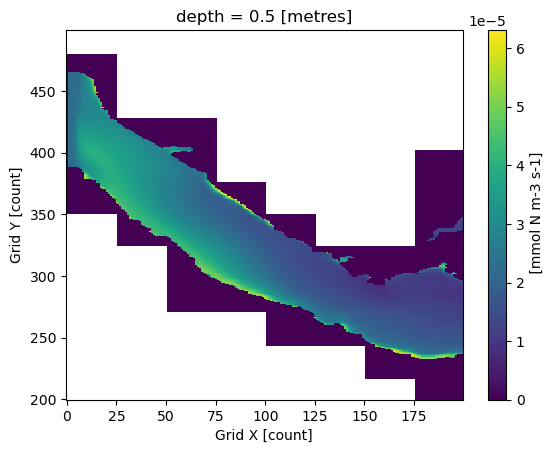

In [10]:
climate[0, 200:500, 0:200].plot();

In [11]:
numerator = np.nansum(
    np.array(climate[0:km, ii1:ii2, jj1:jj2]) * np.array(volume[0, 0:km, ii1:ii2, jj1:jj2]))

In [12]:
climatology_average_productivity = numerator/denominator * 86400
climatology_average_productivity

np.float64(0.3346977242873176)

In [13]:
month = smonth
endday = 30
hw2014 = xr.open_dataset(
        f'/results2/SalishSea/month-avg.202111/SalishSeaCast_1m_prod_T_20140{month}01_20140{month}{endday}.nc')
hw2015 = xr.open_dataset(
        f'/results2/SalishSea/month-avg.202111/SalishSeaCast_1m_prod_T_20150{month}01_20150{month}{endday}.nc')
hw2016 = xr.open_dataset(
        f'/results2/SalishSea/month-avg.202111/SalishSeaCast_1m_prod_T_20160{month}01_20160{month}{endday}.nc')
hw2017 = xr.open_dataset(
        f'/results2/SalishSea/month-avg.202111/SalishSeaCast_1m_prod_T_20170{month}01_20170{month}{endday}.nc')
hw = (hw2014.PPDIATNO3[0] + hw2015.PPDIATNO3[0] + hw2016.PPDIATNO3[0] + hw2017.PPDIATNO3[0] +
      hw2014.PPPHYNO3[0] + hw2015.PPPHYNO3[0] + hw2016.PPPHYNO3[0] + hw2017.PPPHYNO3[0])/ 4.

In [15]:
for month in range(smonth+1, emonth+1):
    if month in [5, 7, 8]:
        endday = 31
    elif month in [4, 6, 9]:
        endday = 30
    
    hw2014 = xr.open_dataset(
        f'/results2/SalishSea/month-avg.202111/SalishSeaCast_1m_prod_T_20140{month}01_20140{month}{endday}.nc')
    hw2015 = xr.open_dataset(
        f'/results2/SalishSea/month-avg.202111/SalishSeaCast_1m_prod_T_20150{month}01_20150{month}{endday}.nc')
    hw2016 = xr.open_dataset(
        f'/results2/SalishSea/month-avg.202111/SalishSeaCast_1m_prod_T_20160{month}01_20160{month}{endday}.nc')
    hw2017 = xr.open_dataset(
        f'/results2/SalishSea/month-avg.202111/SalishSeaCast_1m_prod_T_20170{month}01_20170{month}{endday}.nc')

    hw = hw + (hw2014.PPDIATNO3[0] + hw2015.PPDIATNO3[0] + hw2016.PPDIATNO3[0] + hw2017.PPDIATNO3[0] +
          hw2014.PPPHYNO3[0] + hw2015.PPPHYNO3[0] + hw2016.PPPHYNO3[0] + hw2017.PPPHYNO3[0])/ 4.

In [16]:
hw = hw/6   # for the 6 months we've added together

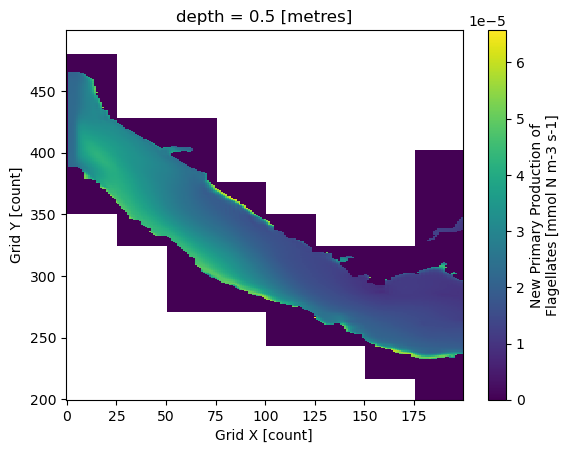

In [17]:
hw[0, 200:500, 0:200].plot();

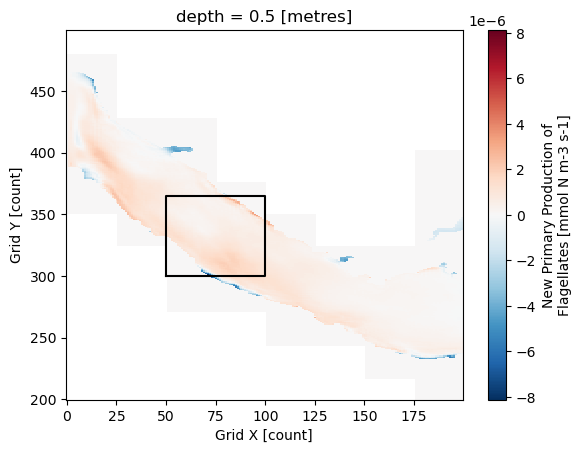

In [21]:
(hw[0, 200:500, 0:200] - climate[0, 200:500, 0:200]).plot();
plt.plot([jj1, jj2, jj2, jj1, jj1], [ii1, ii1, ii2, ii2, ii1], '-k')

In [22]:
numerator_hw = np.nansum(
    np.array(hw[0:km, ii1:ii2, jj1:jj2]) * np.array(volume[0, 0:km, ii1:ii2, jj1:jj2]))

In [23]:
hw_average_productivity = numerator_hw/denominator * 86400
hw_average_productivity

np.float64(0.34548339620051194)

In [24]:
# Central part of JdF Strait about 60 km long
# Currents in July in upper JdF about 30 cm/s based on Thomson et al 2007 Fig 6
time = 60e3/0.3 / 86400 # in days
time

2.314814814814815

In [25]:
time * (hw_average_productivity - climatology_average_productivity)

np.float64(0.02496683313239433)

In [26]:
time * (hw_average_productivity - climatology_average_productivity) / 0.47

np.float64(0.05312092155828581)